# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Nessa projeto foi construído um modelo que nos ajuda a prever doenças cardiovasculares. A base usada contém dados reais, organizados da seguinte maneira:
- age - idade dos pacientes
- gender - genero (2 mulheres) (1 homens)
- height - altura dos pacientes
- weight - peso dos pacientes
- gluc - glicose
- smoke - fumante (1) não fumante (0)
- alco - consume alcool (1) não consome (0)
- active - realiza atividades fisicas (1) não realiza (0)
- cardio_disease - tem doença cardio (1) não tem (0) - Variável target

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Tratamento dos dados/Pré-processamento


In [91]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

O primeiro passo foi corrigir os tipos das variáveis. OCmo evidenciado a seguir, a única variável com tipo inadequado era a "weight", de peso. Para corrigir, ofi necessário trocar todas as "," por ".", para que os valores ficassem de acordo ocm a convenção americana. Como alguns valores tem números decimais, o tipo foi alterado para float, não int, como as outras. 

In [92]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [93]:
base["weight"] = base["weight"].str.replace(",", ".").astype(float)


In [94]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


## Dados faltantes
Por vezes, nem todos os campos das bases tem dados. Por isso , é essencial averigar a presençaa de vaores errados, nulos ou de espaços em branco. Primeiro, a partir das informações da info() acima, é sabido que a base não tem números nulos. Abaixo eu conferi novamente se havia algum dado nulo, apenas por precaução. Após, verificou-se se algum valor era não numérico, supondo que, segundo indicado no iníco do projeto, todos os valores deveriam ser numéricos, ou boleanos. 

In [95]:
print(base.isnull().sum())

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64


In [ ]:
for column in base.columns:
    for value in base[column]:
        if column != "weight" and base[column].dtype != 'int64':
            print(f"{column} contém valor não numérico.") 
        elif column == "weight" and base[column].dtype != 'float64':
            print(f"{column} contém valor não numérico.")


## Outliers
O primeiro passo para a identificação de outliers é a análise do retornjo da função describe(). A média, valor máximo e mínimo de todas as variáveis discretas apresentaram o comportamente esperado. 
O valor máximo de height, altura, é 250 cm, ou seja , 2,5m, e do peso, 200Kg, propvavelmente são outliers. Pela avaliação do boxplot desses campos, evidenciandoevidenciou-se o  comportamento de outlier. 

In [97]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [98]:
import plotly.express as px

In [99]:
fig = px.box(base, y='weight', title='Box Plot do Peso', labels={'weight': 'Peso (kg)'})
fig.show()

In [100]:
fig = px.box(base, y='height', title='Box Plot da Altura', labels={'height': 'Altura (cm)'})
fig.show()

### Correção dos Outliers

Nessa etapa, é crítica a análise de quais valores serão considerados outliers. Isso pode ser feito analisando o conjunto de dados acima e abaixo de 75% e 25%, respectivamente. A análise desses valores indicam se os dados que se destacam são pontos fora da curva, ou apenas valores altos.
Identificado os outliers, há duas formas de corrigí-los: exclusão ou substituição. 
Para verificar a possibildade de exclusão, foi avaliado o percentual que os dados outliers representam em relação à base total.



#### Altura

Os valores mais altos da Altura estão concentrados na média 175 cm, valor próximo ao 75% identificado anteriormente. O desvio padrão é pequeno, o que reforça a tese de que estão concentrados na média. Ao considerar o que previamente se conhece sobre a distribuição de altura da população em geral, optou-se por não excluir todos os valores acima de 75%, afinal, são alturas razoáveis, possíveis. Foi excluído apenas o valor 250cm, por ele ser um valor irreal, e estar isolado muito a cima dos demais.

Para os valores menores do que 25%, o comportamento foi similar. Contudo, a análise é mais delicada, pois não foi explicitado se o modelo deve considerar crianças, ou apenas adultos. Como os dados se concentram em valores de alturas típicas de pessoas adultas, optou-se por excluir os valores abaixo de um limite especificado que não prejudique a basse. Essa escolha torna o modelo menos eficiente para pessoas com nanismo, especialmente os casos mais graves, de maneira que um banco de dados mais robusto e voltado para essa população pode contribuir para o enriquecimento do modelo.

Para determinar esse limite de corte, escolheu-se um valor que não elimine mais do que 10% do banco de dados.

In [112]:
base[["height"]].describe()

,height
count,9978.000000
mean,164.395871
std,7.822017
min,140.000000
25%,159.000000
50%,165.000000
75%,170.000000
max,198.000000


In [102]:
outlier = base["height"][base["height"] > 170]
outlier.describe()


count    1861.000000
mean      175.846857
std         4.521713
min       171.000000
25%       173.000000
50%       175.000000
75%       178.000000
max       250.000000
Name: height, dtype: float64

In [103]:
outlier = base["height"][base["height"] < 159]
outlier.describe()

count    2402.000000
mean      154.053289
std         5.011822
min        70.000000
25%       152.000000
50%       155.000000
75%       157.000000
max       158.000000
Name: height, dtype: float64

In [104]:
outlier = base["height"][base["height"] < 140]
100*len(outlier)/len(base)

0.21

In [105]:
base = base[(base["height"] != 250)]
base = base[base["height"] >= 140]
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9978.000000,9978.000000,9978.000000,9978.000000,9978.000000,9978.000000,9978.000000,9978.000000,9978.000000,9978.000000
mean,53.294548,1.345159,164.395871,74.295761,1.365304,1.222590,0.088996,0.053818,0.796953,0.503407
std,6.791835,0.475444,7.822017,14.507261,0.677941,0.566039,0.284752,0.225670,0.402287,0.500013
min,30.000000,1.000000,140.000000,37.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,198.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Peso

Da análise visual do gráfico, optou-se por não excluir nenhum dado. Os principais outliers são valores superiores, que representam pessoas com muito peso. Como a obesidade está fortemente relacionada a doenças cardiácas, foi decidido não excluir num dado. No futuro, será necessário focar em um banco de dados voltado para essa, e outras populações, de risco com padrões de altura e peso que divergem da norma.

# 2) Análise Bivariada e Matriz de correlação

bem propavel terei que usar algo ocmo o encoder ou o hotlabel
as variáveis categóricas já astão encoded.
antes de escolher, é importante avaliar a matriz de correlação. todas as variáveis já estão codificadas em números, até mesmo as categóricas.
destacam-se as relações entre a cardio_disease

discutir mais a matriz



AS VARIÁVEIS COM correlação mais amrcantes são idade, colesteroal e peso.as analisees serao delas.

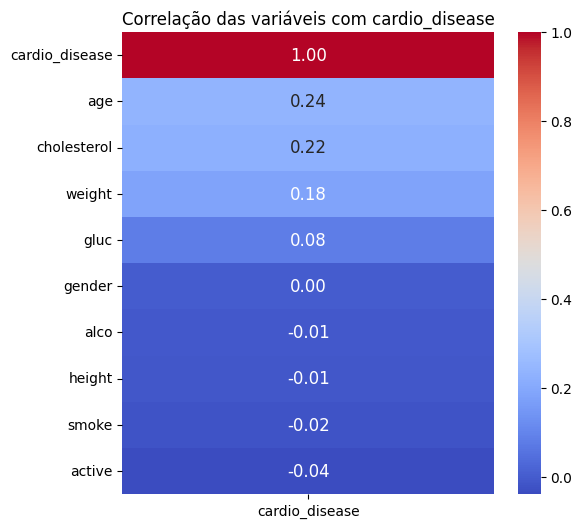

In [126]:
correlation_matrix = base.corr()
column = 'cardio_disease'
correlation_cardio = correlation_matrix[[column]].sort_values(by=column, ascending=False)

plt.figure(figsize=(6, 6))
sns.heatmap(correlation_cardio, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 12})
plt.title(f'Correlação das variáveis com {column}')
plt.show()

### Relação entre Doenças Cardíacas e Idade



In [173]:
fig = px.histogram(base, x='age', color='cardio_disease', barmode='group', nbins=25, histnorm='percent')

# Layout
fig.update_layout(title='Distribuição da Idade por Doença Cardíaca',
                  xaxis_title='Idade',
                  yaxis_title='Contagem',
                  legend_title='Doença Cardíaca'
                 )
fig.show()

## Análise 2
o comportamento da variável cardio com outras variaveis da sua preferência e trazer insights acerca do analisado.

In [184]:
base = base.sort_values(by="cholesterol", ascending=True)


In [185]:
fig = px.histogram(base, x='cardio_disease', color='cholesterol', barmode='group', nbins=3, histnorm='percent')
fig.update_layout(title='Distribuição de Doenças por Colesterol',
                  xaxis_title='Doença Cardíaca',
                  yaxis_title='Contagem',
                  legend_title='Colesterol',
                 )
fig.show()

## Análise 3
fazer a correlação com altura e peso para escolher qual será avaliada
o comportamento da variável cardio com outras variaveis da sua preferência e trazer insights acerca do analisado.

In [188]:
fig = px.histogram(base, x='weight', color='cardio_disease', barmode='group', nbins=15, histnorm='percent')

# Layout
fig.update_layout(title='Distribuição do Peso por Doença Cardíaca',
                  xaxis_title='Peso',
                  yaxis_title='Contagem',
                  legend_title='Doença Cardíaca'
                 )
fig.show()

In [106]:
# seu código aqui

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



In [107]:
# seu código aqui

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [108]:
# seu código aqui

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [109]:
# seu código aqui

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [110]:
# seu código aqui

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



In [111]:
# seu código aqui